In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [37]:
df = pd.read_csv('../data/german_credit_data.csv')
df.drop(columns=['Unnamed: 0'], inplace=True)

In [38]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,NaN,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,NaN,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car


In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               1000 non-null   int64
 1   Sex               1000 non-null   str  
 2   Job               1000 non-null   int64
 3   Housing           1000 non-null   str  
 4   Saving accounts   817 non-null    str  
 5   Checking account  606 non-null    str  
 6   Credit amount     1000 non-null   int64
 7   Duration          1000 non-null   int64
 8   Purpose           1000 non-null   str  
dtypes: int64(4), str(5)
memory usage: 95.9 KB


In [40]:
df.isnull().sum()

Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
dtype: int64

In [41]:
df.fillna('Desconhecido', inplace=True)

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,Desconhecido,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,Desconhecido,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car
...,...,...,...,...,...,...,...,...,...
995,31,female,1,own,little,Desconhecido,1736,12,furniture/equipment
996,40,male,3,own,little,little,3857,30,car
997,38,male,2,own,little,Desconhecido,804,12,radio/TV
998,23,male,2,free,little,little,1845,45,radio/TV


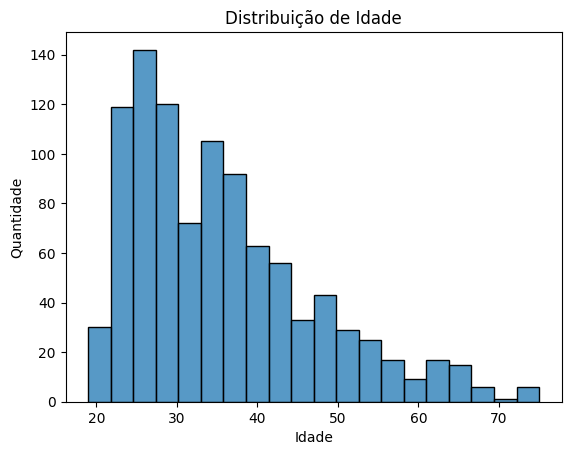

In [42]:
sns.histplot(df['Age'], bins=20)

plt.title('Distribuição de Idade')

plt.xlabel('Idade')

plt.ylabel('Quantidade')

plt.show()

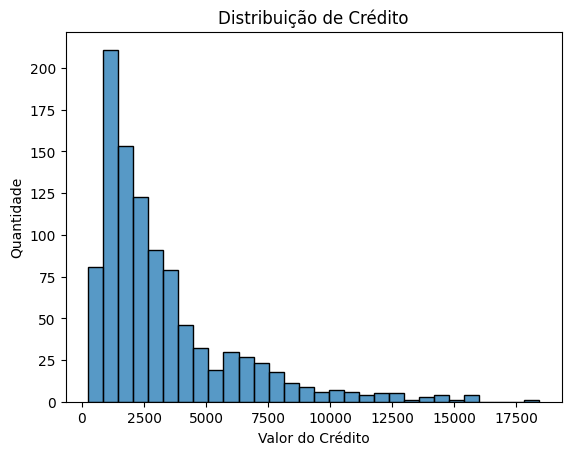

In [43]:
sns.histplot(df['Credit amount'], bins=30)

plt.title('Distribuição de Crédito')

plt.xlabel('Valor do Crédito')

plt.ylabel('Quantidade')

plt.show()

In [44]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

colunas_categoricas = [
    'Sex',
    'Housing',
    'Saving accounts',
    'Checking account',
    'Purpose'
]

for coluna in colunas_categoricas:
    df[coluna] = le.fit_transform(df[coluna].astype(str))

In [45]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,1,2,1,0,1,1169,6,5
1,22,0,2,1,1,2,5951,48,5
2,49,1,1,1,1,0,2096,12,3
3,45,1,2,0,1,1,7882,42,4
4,53,1,2,0,1,1,4870,24,1


In [46]:
scaler = StandardScaler()

dados_normalizados = scaler.fit_transform(df)

In [47]:
inertia = []

K = range(1, 11)

for k in K:
    modelo = KMeans(n_clusters=k, random_state=42)
    modelo.fit(dados_normalizados)
    inertia.append(modelo.inertia_)

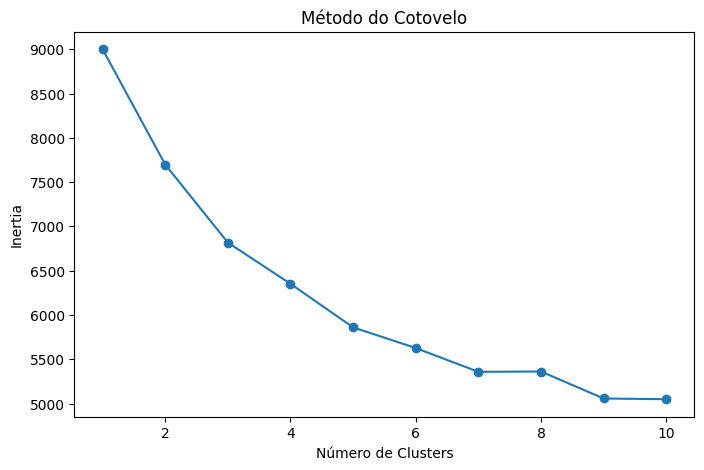

In [48]:
plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker='o')

plt.title('Método do Cotovelo')

plt.xlabel('Número de Clusters')

plt.ylabel('Inertia')

plt.show()

In [49]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(dados_normalizados)

In [50]:
df['Cluster'] = clusters

In [51]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Cluster
0,67,1,2,1,0,1,1169,6,5,1
1,22,0,2,1,1,2,5951,48,5,0
2,49,1,1,1,1,0,2096,12,3,1
3,45,1,2,0,1,1,7882,42,4,0
4,53,1,2,0,1,1,4870,24,1,0


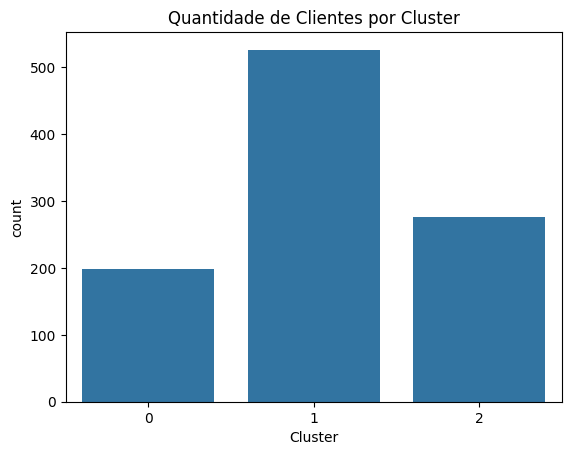

In [52]:
sns.countplot(x='Cluster', data=df)

plt.title('Quantidade de Clientes por Cluster')

plt.show()

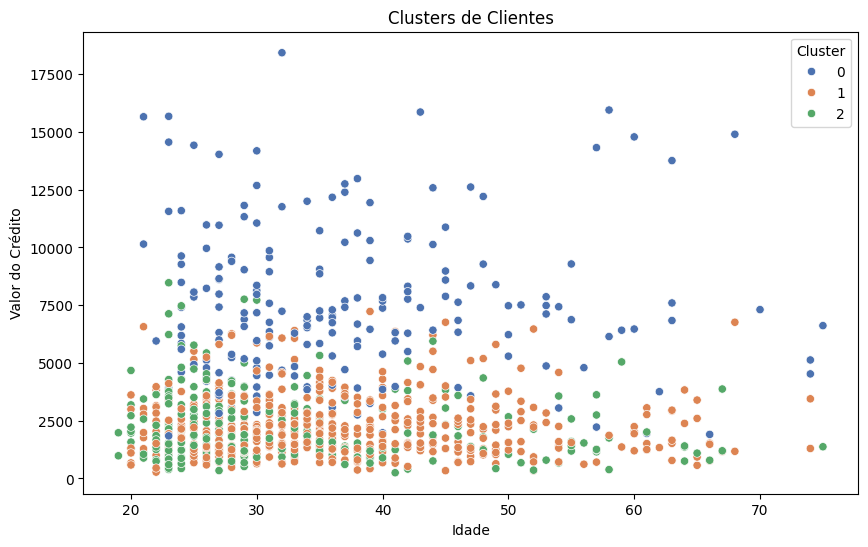

In [53]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['Age'],
    y=df['Credit amount'],
    hue=df['Cluster'],
    palette='deep'
)

plt.title('Clusters de Clientes')

plt.xlabel('Idade')

plt.ylabel('Valor do Crédito')

plt.show()

In [54]:
df.groupby('Cluster').mean()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
Cluster,,,,,,,,,
0,37.287879,0.828283,2.313131,0.818182,0.959596,1.121212,7510.808081,37.686869,2.095960
1,36.589354,1.000000,1.817490,1.053232,1.249049,0.950570,2242.186312,16.673004,3.026616
2,32.307971,0.000000,1.775362,1.286232,1.242754,1.010870,2191.043478,16.923913,3.155797


In [55]:
import joblib

joblib.dump(kmeans, '../model/kmeans_model.pkl')

joblib.dump(scaler, '../model/scaler.pkl')

['../model/scaler.pkl']